# Double Descent Analysis

In [29]:
import sys
sys.path.insert(0, '../')

import numpy as np
from src import data, experiments, plotting

## Setup

Generate the synthetic dataset and define the dimension range for experiments.

In [30]:
# Parameters: n samples, test across d from 5 to 200 features (step of 5)
n = 100
d_values = list(range(5, 205, 5))

# Generate full dataset with max 205 features
X_tr_full, y_tr, X_te_full, y_te = data.generate_synthetic_dataset(n, 205, seed=30)

print(f"Dataset generated:")
print(f"  Training set: {X_tr_full.shape[0]} samples, {X_tr_full.shape[1]} features")
print(f"  Test set: {X_te_full.shape[0]} samples, {X_te_full.shape[1]} features")
print(f"  Dimension range: {d_values[0]} to {d_values[-1]}")

Dataset generated:
  Training set: 100 samples, 205 features
  Test set: 100 samples, 205 features
  Dimension range: 5 to 200


## 1. Classical OLS Implementation

Train OLS model with increasing dimensionality.

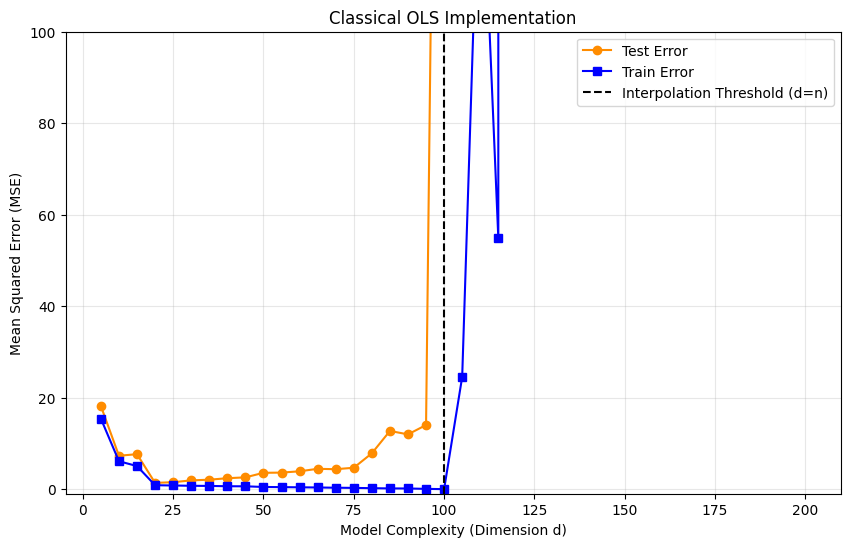

In [31]:
# Run OLS across all dimensions
train_errors, test_errors = experiments.run_ols_experiment(X_tr_full, y_tr, X_te_full, y_te, d_values)

# Plot the classical U-shaped bias-variance tradeoff
plotting.plot_ols_experiment(d_values, train_errors, test_errors, n)

## 2. Ridge Regression

Train Ridge regression model to stabilize the solution in the over-parameterized regime.

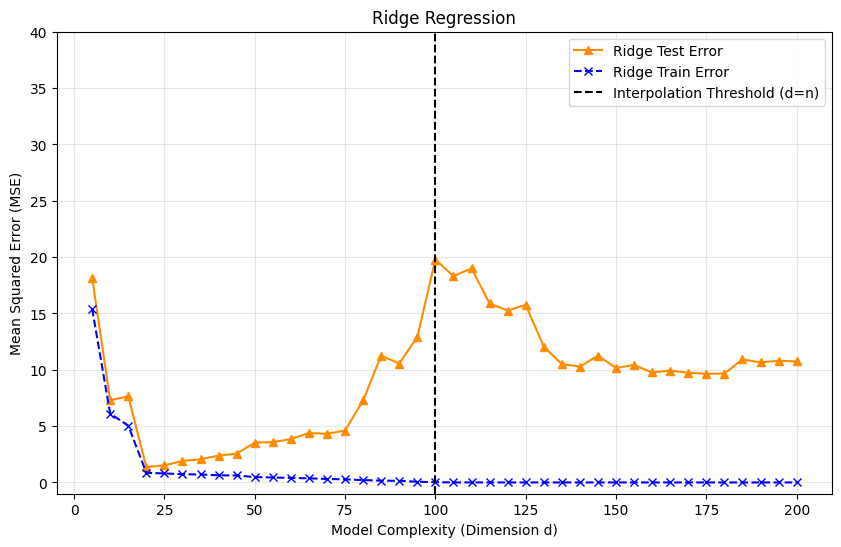

In [32]:
# Ridge regression with alpha=0.1 regularization
ridge_train_errors, ridge_test_errors = experiments.run_ridge_experiment(
    X_tr_full, y_tr, X_te_full, y_te, d_values, alpha=0.1
)

# L2 penalty prevents the divergence seen in OLS
plotting.plot_ridge_experiment(d_values, ridge_train_errors, ridge_test_errors, n)

## 3. OLS vs Ridge Comparison

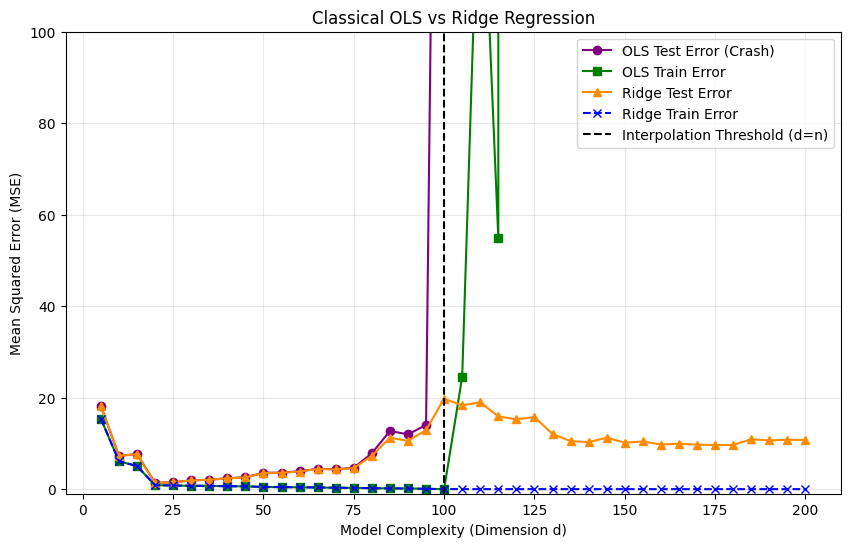

In [33]:
# Show how regularization resolves the singularity problem
plotting.plot_ols_vs_ridge(d_values, train_errors, test_errors, 
                           ridge_train_errors, ridge_test_errors, n)

## 4. Minimum Norm Interpolator (Double Descent)

Use the closed-form minimum norm solution from Belkin et al.

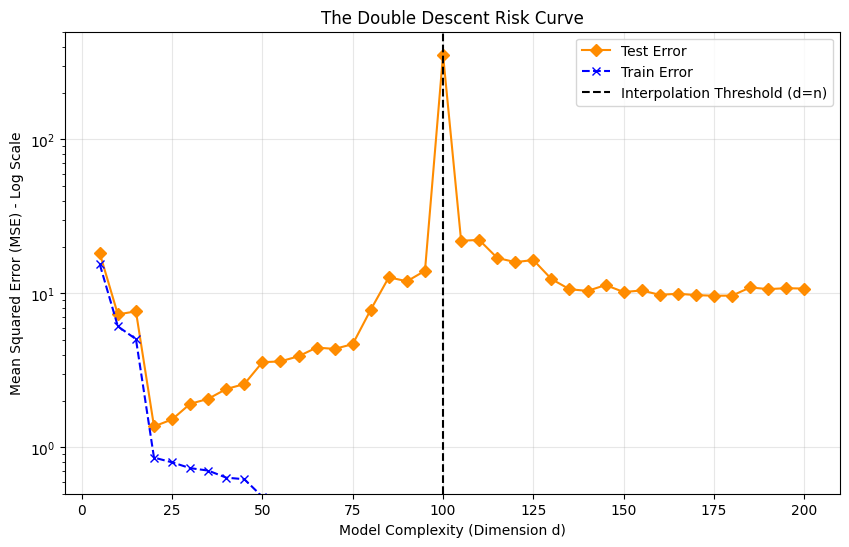

In [34]:
# Minimum norm solution that perfectly fits training data
# Uses OLS for d <= n, and X^T (XX^T)^{-1} y for d > n
dd_train_errors, dd_test_errors, dd_norms = experiments.run_min_norm_experiment(
    X_tr_full, y_tr, X_te_full, y_te, d_values
)

# Log scale to visualize both under and over-parameterized regimes
plotting.plot_double_descent(d_values, dd_train_errors, dd_test_errors, n)

## 5. Weights Norm Analysis

Track the L2 norm of weights to understand the inductive bias.

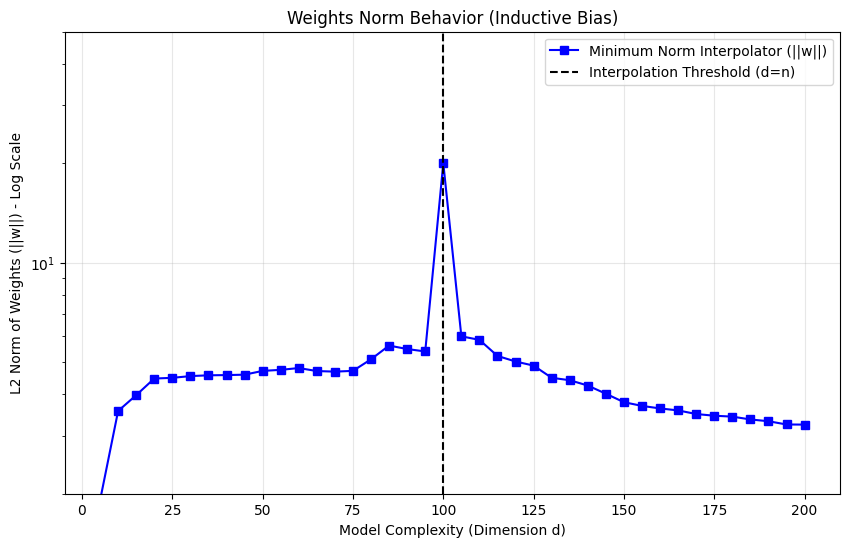

In [35]:
# Weight norm explains the double descent: simpler solutions (smaller norm)
# lead to better generalization in the over-parameterized regime
plotting.plot_weights_norm(d_values, dd_norms, n)

## 6. Gradient Descent vs Closed-Form

Compare iterative gradient descent with the closed-form minimum norm solution.

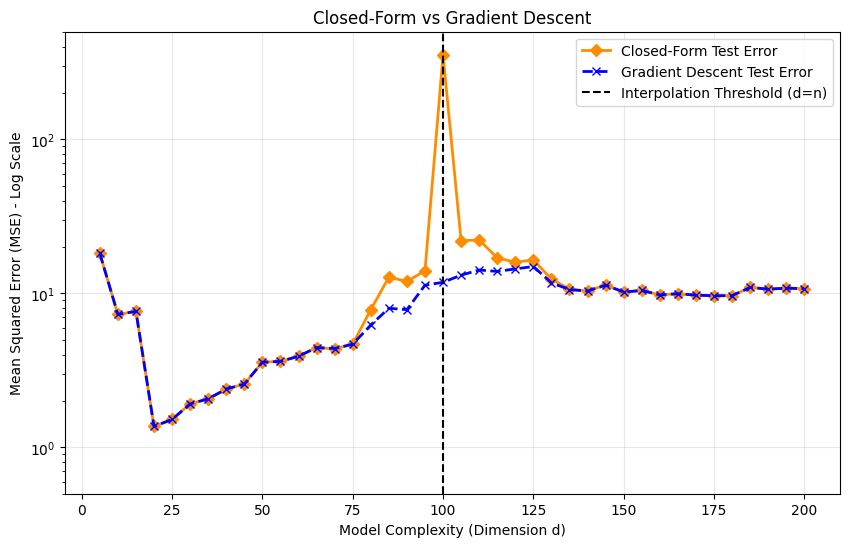

In [ ]:
# Gradient descent from zero converges to min-norm solution
gd_train_errors, gd_test_errors = experiments.run_gradient_descent_experiment(
    X_tr_full, y_tr, X_te_full, y_te, d_values, learning_rate=0.01, epochs=5000
)

plotting.plot_closed_form_vs_gd(d_values, dd_test_errors, gd_test_errors, n)

## 7. Effect of Noise

Explore how noise level affects the double descent phenomenon.

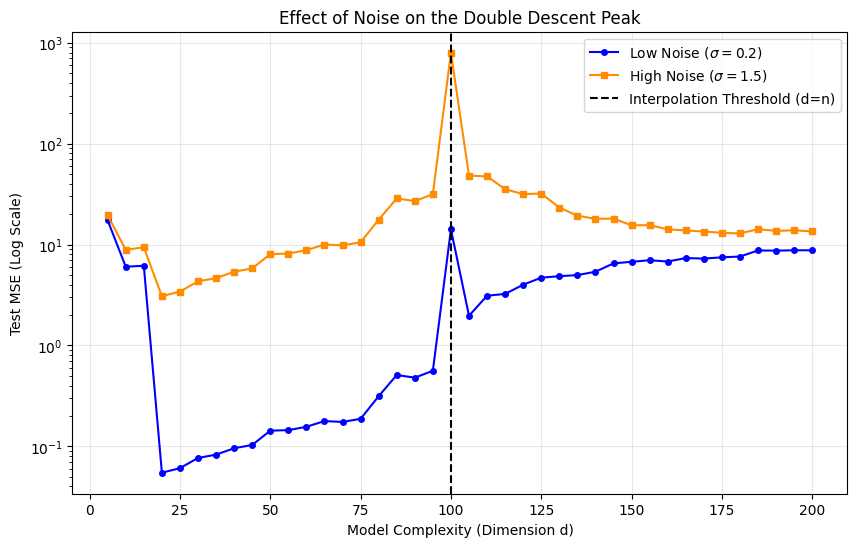

In [ ]:
# Generate datasets with different noise levels
noise_scenarios = {}

for sigma in [0.2, 1.5]:
    # Low noise (0.2) vs high noise (1.5)
    X_tr_f, y_tr_f, X_te_f, y_te_f = data.generate_synthetic_dataset(
        n=100, d=205, noise_level=sigma, seed=30
    )
    
    _, test_errors_noise, _ = experiments.run_min_norm_experiment(
        X_tr_f, y_tr_f, X_te_f, y_te_f, d_values
    )
    
    noise_scenarios[sigma] = test_errors_noise

# High noise makes the peak at d=n much more extreme
plotting.plot_noise_effect(d_values, noise_scenarios, n)